In [72]:
import pandas as pd
import matplotlib.pyplot as plt

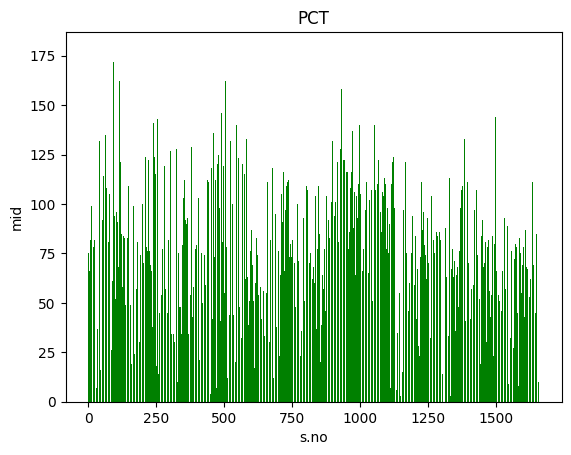

In [73]:
df = pd.read_csv("final1.csv")
df.columns
X = list(df.iloc[:, 0]) 
Y = list(df.iloc[:, 14])
plt.bar(X, Y, color='g') 
plt.title("PCT") 
plt.xlabel("s.no") 
plt.ylabel("mid") 
plt.show()

# Deep Neural Network

In [74]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping


In [75]:
# Load data
data = df.copy()

# Adding new engineered features
data['Avg_Tutorial_Score'] = data[['T1', 'T2', 'T3', 'T4', 'T5']].mean(axis=1)
data['Total_Precomp_Score'] = data['Mid(100)'] + data['Tut (80)'] + data['PCT (180)']
data['Std_Dev_Tutorial_Scores'] = data[['T1', 'T2', 'T3', 'T4', 'T5']].std(axis=1)

# Selecting numerical score columns for features including new features
features = data[['Mid(100)', 'T1', 'T2', 'T3', 'T4', 'T5', 'Tut (80)', 'PCT (180)', 'Avg_Tutorial_Score', 'Total_Precomp_Score', 'Std_Dev_Tutorial_Scores']]
target = data['CT(300)']  # Target variable

# Scale the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(features_scaled, target, test_size=0.2, random_state=42)

# Define the model
model = Sequential([
    Dense(256, input_dim=X_train.shape[1], activation='relu'),
    Dropout(0.3),
    BatchNormalization(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    BatchNormalization(),
    Dense(64, activation='relu'),
    Dropout(0.2),
    BatchNormalization(),
    Dense(1, activation='linear')  # Linear activation for regression
])

# Compile the model
model.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mean_absolute_error'])

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(X_train, y_train, validation_split=0.1, epochs=150, batch_size=32, callbacks=[early_stopping])

# Evaluate the model
evaluation = model.evaluate(X_test, y_test)
print(f'Test Loss: {evaluation[0]}, Test MAE: {evaluation[1]}')


Epoch 1/150


c:\Users\saatv\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 12468.9326 - mean_absolute_error: 100.3280 - val_loss: 11211.5195 - val_mean_absolute_error: 94.8030
Epoch 2/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12670.6387 - mean_absolute_error: 101.7758 - val_loss: 11113.1182 - val_mean_absolute_error: 94.2982
Epoch 3/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12754.9619 - mean_absolute_error: 102.0576 - val_loss: 10987.4707 - val_mean_absolute_error: 93.6495
Epoch 4/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11569.6582 - mean_absolute_error: 96.0230 - val_loss: 10761.2295 - val_mean_absolute_error: 92.4697
Epoch 5/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12166.6094 - mean_absolute_error: 99.2183 - val_loss: 10541.0713 - val_mean_absolute_error: 91.3218
Epoch 6/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11169.7676 - mean_absolute_error: 94.7986 - val_loss: 10189.9121 - val_mean_absolute_error: 89.4633
Epoch 7/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

As we can see the performance of a DNN did not work well for the data, so lets move on to some better approach.

# XGBoost Model

In [76]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import mean_squared_error

data = df.copy()

# Adding new engineered features
data['Avg_Tutorial_Score'] = data[['T1', 'T2', 'T3', 'T4', 'T5']].mean(axis=1)
data['Total_Precomp_Score'] = data['Mid(100)'] + data['Tut (80)'] + data['PCT (180)']
data['Std_Dev_Tutorial_Scores'] = data[['T1', 'T2', 'T3', 'T4', 'T5']].std(axis=1)

# Selecting numerical score columns for features including new features
features = data[['Mid(100)', 'T1', 'T2', 'T3', 'T4', 'T5', 'Tut (80)', 'PCT (180)', 'Avg_Tutorial_Score', 'Total_Precomp_Score', 'Std_Dev_Tutorial_Scores']]
target = data['CT(300)']

# Scale the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(features_scaled, target, test_size=0.2, random_state=42)

# Initialize and train the XGBoost model
xgb_model = xgb.XGBRegressor(objective ='reg:squarederror', colsample_bytree = 0.3, learning_rate = 0.1,
                             max_depth = 5, alpha = 10, n_estimators = 200)

xgb_model.fit(X_train, y_train)

# Evaluate the model
predictions = xgb_model.predict(X_test)
mae = np.mean(np.abs(predictions - y_test))
mse = mean_squared_error(y_test, predictions)
print(f'Test MAE: {mae}')
print(f'Test MSE: {mse}')

Test MAE: 10.170111293534198
Test MSE: 168.00107065986242


# Function to provide study suggestions based on performance thresholds

In [77]:
# Function to provide study suggestions based on performance thresholds
def provide_study_suggestions(data, model, threshold='average'):
    features = data[['Mid(100)', 'T1', 'T2', 'T3', 'T4', 'T5', 'Tut (80)', 'PCT (180)', 'Avg_Tutorial_Score', 'Total_Precomp_Score', 'Std_Dev_Tutorial_Scores']]
    features_scaled = scaler.transform(features)
    predictions = model.predict(features_scaled)
    suggestions = []

    for i, row in data.iterrows():
        actual = row['CT(300)']
        predicted = predictions[i]
        if threshold == 'average':
            threshold_value = data['CT(300)'].mean()
        elif threshold == 'average+':
            threshold_value = data['CT(300)'].mean() + 10  # Adjust this value as needed
        elif threshold == 'average-':
            threshold_value = data['CT(300)'].mean() - 10  # Adjust this value as needed

        if predicted < threshold_value:  # Using predicted score to determine if suggestions are needed
            test_scores = row[['T1', 'T2', 'T3', 'T4', 'T5']]
            min_score_index = test_scores.argmin()
            min_topic = row[f'Topic-{min_score_index + 1}']
            suggestions.append((row['No.'], min_topic))
    return suggestions

study_suggestions = provide_study_suggestions(data, xgb_model)
print("XGB Model Suggestions")
print(study_suggestions)

study_suggestions = provide_study_suggestions(data, model)
print("DNN Model Suggestions")
print(study_suggestions)

XGB Model Suggestions
[(1, 'K&K 2,3'), (4, 'K&K 4'), (5, 'A.P F 5'), (6, 'K&K 2,3'), (11, 'A.P F 5'), (21, 'K&K 2,3'), (22, 'K&K 2,3'), (25, 'K&K 2,3'), (31, 'K&K 2,3'), (35, 'K&K 2,3'), (36, 'K&K 2,3'), (37, 'K&K 6'), (41, 'K&K 2,3'), (43, 'K&K 2,3'), (44, 'K&K 4'), (46, 'K&K 2,3'), (47, 'K&K 2,3'), (48, 'K&K 6'), (49, 'K&K 4'), (52, 'A.P F 5'), (54, 'A.P F 5'), (56, 'K&K 2,3'), (61, 'A.P F 5'), (63, 'K&K 2,3'), (67, 'K&K 2,3'), (70, 'K&K 2,3'), (71, 'K&K 4'), (73, 'K&K 2,3'), (75, 'K&K 4'), (76, 'A.P F 3,4'), (78, 'K&K 2,3'), (81, 'K&K 2,3'), (82, 'K&K 4'), (86, 'K&K 4'), (89, 'K&K 4'), (90, 'K&K 2,3'), (91, 'A.P F 5'), (93, 'K&K 4'), (96, 'K&K 2,3'), (98, 'K&K 2,3'), (99, 'K&K 2,3'), (101, 'A.P F 3,4'), (104, 'K&K 4'), (106, 'K&K 2,3'), (107, 'K&K 4'), (109, 'K&K 2,3'), (111, 'K&K 2,3'), (112, 'A.P F 3,4'), (114, 'A.P F 5'), (117, 'A.P F 5'), (118, 'A.P F 5'), (122, 'K&K 2,3'), (124, 'K&K 6'), (125, 'K&K 2,3'), (127, 'K&K 2,3'), (128, 'K&K 2,3'), (129, 'K&K 4'), (131, 'K&K 4'), (133

Testing on Second Dataset

In [78]:
df_alt = pd.read_csv("dataset2_final.csv")
data1 = df.copy()

# Adding new engineered features
data1['Avg_Tutorial_Score'] = data1[['T1', 'T2', 'T3', 'T4', 'T5']].mean(axis=1)
data1['Total_Precomp_Score'] = data1['Mid(100)'] + data1['Tut (80)'] + data1['PCT (180)']
data1['Std_Dev_Tutorial_Scores'] = data1[['T1', 'T2', 'T3', 'T4', 'T5']].std(axis=1)

# Selecting numerical score columns for features including new features
features = data1[['Mid(100)', 'T1', 'T2', 'T3', 'T4', 'T5', 'Tut (80)', 'PCT (180)', 'Avg_Tutorial_Score', 'Total_Precomp_Score', 'Std_Dev_Tutorial_Scores']]
target = data1['CT(300)']  # Target variable

# Scale the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(features_scaled, target, test_size=0.2, random_state=42)

y_pred = xgb_model.predict(X_test)
print(y_pred)
y_pred1 = xgb_model.predict(X_train)
print(y_pred1)


[ 79.48847    59.49068    94.821945  193.80414    71.72568   123.5411
  89.47927   153.82076   107.24839    17.69858    47.687984   82.77477
  82.418915   33.71728   155.10918    36.173237   65.878235   75.12119
  51.288662  170.57063    67.20061   151.49376   196.71446    33.33226
  76.614265  100.69518    67.88739   127.57869    47.152622  108.07933
 146.42676   106.55031   116.53528    74.37094   137.9203     56.204582
 174.44792    12.461522   64.8396    132.40756   170.03587    34.21057
 151.58096   112.53976    93.016754  160.13107   114.344826  129.48997
 100.14272   118.10121    80.338005   49.137627  167.26364    14.73928
  91.68962   127.821594   88.838       7.3482065 131.24141   136.77943
  92.84253   134.29489    49.62016   161.23813    36.610153   39.60743
  68.551285  125.361015   97.886215   95.8278     77.94256    75.20812
  60.18146    74.23739   127.271034  189.46928    35.594418   51.118366
 131.1118    158.59247   150.26318   181.79356   126.59295   141.11792
 146.

In [79]:
def mean_absolute_error(actual_values, predicted_values):
    """
    Calculate the Mean Absolute Error (MAE) between actual and predicted values.

    Parameters:
        actual_values (list): List of actual values.
        predicted_values (list): List of predicted values.

    Returns:
        float: Mean Absolute Error (MAE).
    """
    if len(actual_values) != len(predicted_values):
        raise ValueError("Length of actual_values and predicted_values must be the same.")

    error_sum = 0.0
    for actual, predicted in zip(actual_values, predicted_values):
        error_sum += abs(actual - predicted)

    mae = error_sum / len(actual_values)
    return mae

mae1 = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae1)

mae2 = mean_absolute_error(y_train, y_pred1)
print("Mean Absolute Error:", mae2)

Mean Absolute Error: 10.170111293534198
Mean Absolute Error: 4.704252586825041
